## Importar API da Base dos Dados



In [2]:
!pip install basedosdados

## Controle de Versão

In [3]:
# --- TÓPICO 0: CONFIGURAÇÕES DE AMBIENTE E REPRODUTIBILIDADE ---
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import pandas_gbq
import basedosdados
import matplotlib
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_utils import (
    carregar_snis,
    preparar_populacao_referencia,
    calcular_flags_evidencia,
    limpar_df_gold,
    processar_saude,
    integrar_saude_tabnet,
    calcular_risco_social_final,
    validar_populacao,
    classificar_qualidade_populacao,
    analisar_municipio,
 )

# 1. Registro de Versões (Garante que você saiba em qual ambiente o código funcionou)
print(f"📌 Pandas: {pd.__version__}")
print(f"📌 Numpy: {np.__version__}")
print(f"📌 Pandas-GBQ: {pandas_gbq.__version__}")
print(f"📌 Matplotlib: {matplotlib.__version__}") 


# 2. Comando para gerar o requirements.txt (Rode se quiser exportar para outro ambiente)
# !pip freeze > requirements.txt

# 3. Configurações Globais do Pandas (Para evitar comportamentos inesperados)
try:
    pd.set_option('future.no_silent_downcasting', True)
except Exception:
    print("INFO: Opcao future.no_silent_downcasting nao existe nesta versao do pandas.")

📌 Pandas: 2.1.4
📌 Numpy: 1.26.4
📌 Pandas-GBQ: 0.35.0
📌 Matplotlib: 3.8.0
INFO: Opcao future.no_silent_downcasting nao existe nesta versao do pandas.


## Autenticar usuário

In [4]:
import pandas_gbq

try:
    from google.colab import auth
except ModuleNotFoundError:
    print("INFO: Google Colab nao detectado; pulando autenticacao.")
else:
    auth.authenticate_user()
    print("Autenticado com sucesso!")

INFO: Google Colab nao detectado; pulando autenticacao.


# Saneamento: Água e Esgoto

## Importar Base de Dados

In [5]:
# Seu ID corrigido (garanta que não haja espaços antes ou depois)
import pandas_gbq

PROJECT_ID = "analise-saneamento"

# SQL otimizada: seleciona apenas colunas usadas e filtra UF/ano na origem
sql = """
SELECT
  ano,
  id_municipio,
  sigla_uf,
  quantidade_economia_residencial_ativa_agua,
  quantidade_economia_residencial_ativa_esgoto,
  quantidade_ligacao_total_agua,
  quantidade_ligacao_total_esgoto,
  populacao_urbana,
  populacao_atendida_agua,
  indice_atendimento_total_agua,
  indice_atendimento_esgoto_agua,
  indice_atendimento_urbano_agua,
  indice_tratamento_esgoto,
  indice_perda_distribuicao_agua,
  indice_consumo_agua_per_capita,
  volume_esgoto_coletado,
  volume_esgoto_tratado,
  extensao_rede_agua,
  extensao_rede_esgoto,
  populacao_atentida_esgoto AS populacao_urbana_atendida_esgoto,
  quantidade_ligacao_ativa_esgoto,
  investimento_total_municipio,
  investimento_total_estado,
  investimento_total_prestador,
  despesa_exploracao,
  arrecadacao_total,
  receita_operacional
FROM `basedosdados.br_mdr_snis.municipio_agua_esgoto`
WHERE sigla_uf = 'ES' AND ano >= 2006
"""

try:
    df = pandas_gbq.read_gbq(sql, project_id=PROJECT_ID)
    print("Sucesso! Dados do ES carregados.")
    display(df.head())
except Exception as e:
    raise RuntimeError(f"Erro ao acessar a tabela de saneamento: {e}")


Downloading: 100%|██████████|
Sucesso! Dados do ES carregados.


,ano,id_municipio,sigla_uf,quantidade_economia_residencial_ativa_agua,quantidade_economia_residencial_ativa_esgoto,quantidade_ligacao_total_agua,quantidade_ligacao_total_esgoto,populacao_urbana,populacao_atendida_agua,indice_atendimento_total_agua,...,extensao_rede_agua,extensao_rede_esgoto,populacao_urbana_atendida_esgoto,quantidade_ligacao_ativa_esgoto,investimento_total_municipio,investimento_total_estado,investimento_total_prestador,despesa_exploracao,arrecadacao_total,receita_operacional
0,2017,3200706,ES,2265,2018,2642,2480,7329,6873,58.23,...,32.51,39.04,6141,2430,12379.27,0.0,671945.61,1328338.91,1385223.64,1432834.07
1,2018,3201902,ES,4020,2558,4011,2623,8194,8548,25.36,...,56.19,21.66,5767,2155,0.00,0.0,10616656.11,2538340.43,4125369.67,4232494.40
2,2019,3202504,ES,3505,3320,3955,3270,9451,12206,97.81,...,80.00,65.00,9100,2969,0.00,0.0,100337.97,2032452.52,2230868.43,2230868.43
3,2020,3202553,ES,1900,1700,3729,1703,3142,5757,64.98,...,30.00,25.00,5446,1500,0.00,0.0,NaN,638832.31,638832.31,638832.31
4,2020,3204351,ES,2855,2843,3281,2854,7462,7462,38.72,...,28.00,22.00,6442,2643,0.00,0.0,11125.90,1899471.78,1937584.47,1937584.47


## Definindo estrutura do data frame

In [6]:
colunas_selecionadas = [
    # Identificação
    'ano', 'id_municipio', 'sigla_uf',

    # Para identificar comunidades vulneráveis
    'quantidade_economia_residencial_ativa_agua',
    'quantidade_economia_residencial_ativa_esgoto',
    'quantidade_ligacao_total_agua',
    'quantidade_ligacao_total_esgoto',

    # Demografia e Cobertura
    'populacao_urbana',
    'populacao_atendida_agua',
    'indice_atendimento_total_agua',
    'indice_atendimento_esgoto_agua',
    'indice_atendimento_urbano_agua',

    # Qualidade e Performance
    'indice_tratamento_esgoto',
    'indice_perda_distribuicao_agua',
    'indice_consumo_agua_per_capita',
    'volume_esgoto_coletado',
    'volume_esgoto_tratado',

    # Infraestrutura (EVIDÊNCIAS PARA O SCRIPT)
    'extensao_rede_agua',
    'extensao_rede_esgoto',
    'populacao_urbana_atendida_esgoto',
    'quantidade_ligacao_ativa_esgoto',

    # Investimentos
    'investimento_total_municipio',
    'investimento_total_estado',
    'investimento_total_prestador',
    'despesa_exploracao',
    'arrecadacao_total',
    'receita_operacional'
]

df_silver = df[colunas_selecionadas].copy()

# Asserção para garantir que o filtro do SQL foi aplicado
assert df_silver['ano'].min() >= 2006, "Dado fora do intervalo esperado — verificar SQL"
print(f"Novo tamanho do dataset: {df_silver.shape}")


Novo tamanho do dataset: (1267, 27)


## Limpeza dos Dados

In [7]:
# --- TRATAMENTO DE POPULAÇÃO E ESGOTO ---
df_gold = limpar_df_gold(df_silver)

print("Processamento final concluído! Base limpa com interpolação conservadora.")
print("✅ População de referência preparada para o cálculo de morbidade.")

Processamento final concluído! Base limpa com interpolação conservadora.
✅ População de referência preparada para o cálculo de morbidade.


## Integração de Dados de Saúde (TabNet)

In [8]:
# --- CÉLULA 7: INTEGRAÇÃO DATASUS E CÁLCULO DE PESOS EPIDEMIOLÓGICOS ---

# Pesos versionados para evitar deriva histórica silenciosa no dashboard
VERSAO_PESOS = '2025-04'
W_AGUA_CALCULADO = 0.52
W_ESGOTO_CALCULADO = 0.48
RECALCULAR_PESOS = False  # mude para True apenas ao atualizar os CSVs

df_final, W_AGUA, W_ESGOTO = integrar_saude_tabnet(
    df_gold,
    str(PROJECT_ROOT / "data" / "raw" / "saude_agua_es.csv"),
    str(PROJECT_ROOT / "data" / "raw" / "saude_esgoto_es.csv"),
    versao_pesos=VERSAO_PESOS,
    w_agua_calculado=W_AGUA_CALCULADO,
    w_esgoto_calculado=W_ESGOTO_CALCULADO,
    recalcular_pesos=RECALCULAR_PESOS
 )


📊 DIAGNÓSTICO DE COBERTURA
Água: 2007–2022 (16 anos)
Esgoto: 2007–2022 (16 anos)
Interseção: 2007–2022 (16 anos)

⚖️ Pesos utilizados (versão 2025-04):
W_AGUA: 0.520
W_ESGOTO: 0.480

✅ Integração concluída com pesos robustos!


In [23]:
# Qual é o nome real da variável retornada pela integração?
# Substitua df_saude_integrado pelo nome real que você usa
print("Colunas do resultado da integração de saúde:")
print([c for c in df_final.columns if df_final[c].notna().any()])

Colunas do resultado da integração de saúde:
['ano', 'id_municipio', 'sigla_uf', 'quantidade_economia_residencial_ativa_agua', 'quantidade_economia_residencial_ativa_esgoto', 'quantidade_ligacao_total_agua', 'quantidade_ligacao_total_esgoto', 'populacao_urbana', 'populacao_atendida_agua', 'indice_atendimento_total_agua', 'indice_atendimento_esgoto_agua', 'indice_atendimento_urbano_agua', 'indice_tratamento_esgoto', 'indice_perda_distribuicao_agua', 'indice_consumo_agua_per_capita', 'volume_esgoto_coletado', 'volume_esgoto_tratado', 'extensao_rede_agua', 'extensao_rede_esgoto', 'populacao_urbana_atendida_esgoto', 'quantidade_ligacao_ativa_esgoto', 'investimento_total_municipio', 'investimento_total_estado', 'investimento_total_prestador', 'despesa_exploracao', 'arrecadacao_total', 'receita_operacional', 'populacao_ref_bruta', 'flag_insumos_esgoto_incompletos', 'Volume_Esgoto_Nao_Tratado_m3', 'Atendimento_Com_Tratamento_Efetivo_Percentual', 'Deficit_Cobertura_Tratamento_Percentual', 'inv

In [24]:
# Verificar se a taxa existe com outro nome
candidatas = [c for c in df_final.columns 
              if df_final[c].notna().any() 
              and df_final[c].dtype in ['float64', 'int64']
              and df_final[c].max() > 1]
print("Colunas numéricas com dados:")
print(candidatas)

Colunas numéricas com dados:
['indice_atendimento_total_agua', 'indice_atendimento_esgoto_agua', 'indice_atendimento_urbano_agua', 'indice_tratamento_esgoto', 'indice_perda_distribuicao_agua', 'indice_consumo_agua_per_capita', 'volume_esgoto_coletado', 'volume_esgoto_tratado', 'extensao_rede_agua', 'extensao_rede_esgoto', 'investimento_total_municipio', 'investimento_total_estado', 'investimento_total_prestador', 'despesa_exploracao', 'arrecadacao_total', 'receita_operacional', 'Volume_Esgoto_Nao_Tratado_m3', 'Atendimento_Com_Tratamento_Efetivo_Percentual', 'Deficit_Cobertura_Tratamento_Percentual', 'investimento_total_consolidado', 'populacao_ref', 'extensao_rede_esgoto_display', 'Taxa_Morbidade_100k_Hab', 'def_agua', 'eficiencia_esgoto_calc', 'def_esgoto', 'vazio_sanitario', 'indice_combinado', 'RISCO_SOCIAL_FINAL', 'eficiencia_arrecadacao_bruta', 'eficiencia_arrecadacao']


## Engenharia de Risco Social Multidimensional (Água vs. Esgoto)

In [9]:
# --- CÉLULA 8: ENGENHARIA DO RISCO SOCIAL FINAL ---
df_final = calcular_risco_social_final(df_final, W_AGUA, W_ESGOTO)

print("💎 Risco Social Final calculado (modelo robusto)")
print("📊 Escala: 0 a 100")
print("🧠 Proteções: ausência de dados + controle de escala + fallback estrutural")
print("🔎 Flags de truncamento em eficiencia_arrecadacao registradas para auditoria")

💎 Risco Social Final calculado (modelo robusto)
📊 Escala: 0 a 100
🧠 Proteções: ausência de dados + controle de escala + fallback estrutural
🔎 Flags de truncamento em eficiencia_arrecadacao registradas para auditoria


# Comunidades vulneráveis

## Diagnóstico de Vetores Dominantes

In [10]:

# --- DIAGNÓSTICO VETORIZADO DO VETOR DOMINANTE (ROBUSTO A NaN) ---

if 'internacoes_agua' in df_final.columns:
    internacoes_agua = pd.Series(
        pd.to_numeric(df_final['internacoes_agua'], errors='coerce'),
        index=df_final.index
    )
else:
    internacoes_agua = pd.Series(np.nan, index=df_final.index)

if 'internacoes_esgoto' in df_final.columns:
    internacoes_esgoto = pd.Series(
        pd.to_numeric(df_final['internacoes_esgoto'], errors='coerce'),
        index=df_final.index
    )
else:
    internacoes_esgoto = pd.Series(np.nan, index=df_final.index)

if 'tem_dado_saude' in df_final.columns:
    tem_dado_saude = df_final['tem_dado_saude'].fillna(False)
else:
    tem_dado_saude = internacoes_agua.notna() | internacoes_esgoto.notna()

# Sem dado segue apenas a flag consolidada (internações já chegam inteiras da Célula 19).
sem_dados = ~tem_dado_saude
ambos_zero = (~sem_dados) & (internacoes_agua == 0) & (internacoes_esgoto == 0)
vetor_agua = (~sem_dados) & (internacoes_agua > internacoes_esgoto)
empate = (~sem_dados) & (internacoes_agua == internacoes_esgoto) & (internacoes_agua > 0)
vetor_esgoto = (~sem_dados) & (internacoes_agua < internacoes_esgoto)

condicoes = [
    sem_dados,
    ambos_zero,
    vetor_agua,
    empate,
    vetor_esgoto
]

escolhas = [
    'Sem Dados',
    'Baixo Impacto',
    'Vetor Água',
    'Empate',
    'Vetor Esgoto'
]

df_final['vetor_dominante_doenca'] = np.select(condicoes, escolhas, default='Inconsistente')

print('📊 Perfil epidemiológico vetorizado (ES 2022):')
print(df_final[df_final['ano'] == 2022]['vetor_dominante_doenca'].value_counts())
print("⚠️ Registros marcados como 'Inconsistente':", (df_final['vetor_dominante_doenca'] == 'Inconsistente').sum())

📊 Perfil epidemiológico vetorizado (ES 2022):
vetor_dominante_doenca
Vetor Água       76
Empate            1
Baixo Impacto     1
Name: count, dtype: int64
⚠️ Registros marcados como 'Inconsistente': 0


# Validações

In [11]:
# --- VALIDAÇÃO DA POPULAÇÃO DE REFERÊNCIA ---

def validar_populacao(df):
    df = df.sort_values(['id_municipio', 'ano']).copy()

    relatorio = {}

    # 1. Valores inválidos
    invalidos = df[
        (df['populacao_ref'].isna()) |
        (df['populacao_ref'] <= 0)
    ]
    relatorio['valores_invalidos'] = invalidos

    # 2. Crescimento ano a ano (%)
    df['populacao_anterior'] = df.groupby('id_municipio')['populacao_ref'].shift(1)
    df['crescimento_pct'] = (
        (df['populacao_ref'] - df['populacao_anterior']) /
        df['populacao_anterior']
    ) * 100

    crescimento_absurdo = df[
        df['crescimento_pct'].abs() > 20
    ]
    relatorio['crescimento_absurdo'] = crescimento_absurdo

    # 3. Outliers (z-score por município)

    df['outlier'] = df.groupby('id_municipio', group_keys=False)['populacao_ref'].transform(
        lambda s: ((s - s.mean()) / s.std()).abs().gt(3) if pd.notna(s.std()) and s.std() != 0 else pd.Series(False, index=s.index)
    )
    relatorio['outliers'] = df[df['outlier']]

    # 4. Saltos absolutos grandes
    df['delta_abs'] = (df['populacao_ref'] - df['populacao_anterior']).abs()

    salto_grande = df[
        df['delta_abs'] > df['populacao_ref'] * 0.15
    ]
    relatorio['saltos_grandes'] = salto_grande

    # 5. Lacunas originalmente imputadas
    if 'populacao_ref_era_nula' in df.columns:
        relatorio['valores_imputados'] = df[df['populacao_ref_era_nula']]
    else:
        relatorio['valores_imputados'] = df.iloc[0:0].copy()

    print("\n📊 RELATÓRIO DE VALIDAÇÃO DA POPULAÇÃO\n")
    print(f"❌ Valores inválidos: {len(relatorio['valores_invalidos'])}")
    print(f"📈 Crescimentos suspeitos (>20%): {len(relatorio['crescimento_absurdo'])}")
    print(f"📊 Outliers estatísticos: {len(relatorio['outliers'])}")
    print(f"⚠️ Saltos absolutos grandes: {len(relatorio['saltos_grandes'])}")
    print(f"🩹 Valores imputados/interpolados: {len(relatorio['valores_imputados'])}")

        # Apelidos e coluna adicional para células de classificação posteriores usarem sem recalcular
    df['pop_ant'] = df['populacao_anterior']
    df['pop_prox'] = df.groupby('id_municipio')['populacao_ref'].shift(-1)

    return relatorio, df

# Valida a base que será efetivamente exportada
relatorio, df_validado = validar_populacao(df_final)


📊 RELATÓRIO DE VALIDAÇÃO DA POPULAÇÃO

❌ Valores inválidos: 0
📈 Crescimentos suspeitos (>20%): 37
📊 Outliers estatísticos: 12
⚠️ Saltos absolutos grandes: 54
🩹 Valores imputados/interpolados: 0


In [12]:
# municípios mais problemáticos
relatorio['crescimento_absurdo']['id_municipio'].value_counts().head(10)

id_municipio
3201159    3
3200136    1
3204302    1
3203304    1
3203320    1
3203353    1
3204005    1
3204054    1
3204104    1
3204351    1
Name: count, dtype: int64

In [13]:
relatorio['outliers']['id_municipio'].value_counts().head(10)

id_municipio
3200300    1
3200805    1
3202603    1
3202801    1
3203353    1
3204104    1
3204302    1
3204500    1
3204559    1
3204807    1
Name: count, dtype: int64

In [14]:
relatorio['saltos_grandes']['id_municipio'].value_counts().head(10)

id_municipio
3201159    3
3200136    2
3203320    2
3204203    2
3204302    2
3204351    2
3201902    2
3203304    2
3205036    2
3200409    2
Name: count, dtype: int64

In [15]:
def analisar_municipio(df, municipio_id):

    df_m = df[df['id_municipio'].astype(str) == str(municipio_id)].sort_values('ano')

    print(df_m[['ano', 'populacao_ref', 'crescimento_pct']])

    plt.plot(df_m['ano'], df_m['populacao_ref'], marker='o')
    plt.title(f"Município {municipio_id}")
    plt.grid()
    plt.show()


     ano  populacao_ref  crescimento_pct
76  2006         3370.0              NaN
77  2007         3226.0        -4.272997
78  2008         3254.0         0.867948
79  2009         3212.0        -1.290719
80  2010         4256.0        32.503113
81  2011         4272.0         0.375940
82  2012         4287.0         0.351124
83  2013         4561.0         6.391416
84  2014         4588.0         0.591975
85  2015         4615.0         0.588492
86  2016         4641.0         0.563380
87  2017         4666.0         0.538677
88  2018         4536.0        -2.786112
89  2019         4558.0         0.485009
90  2020         4580.0         0.482668
91  2021         4602.0         0.480349
92  2022         3903.0       -15.189048


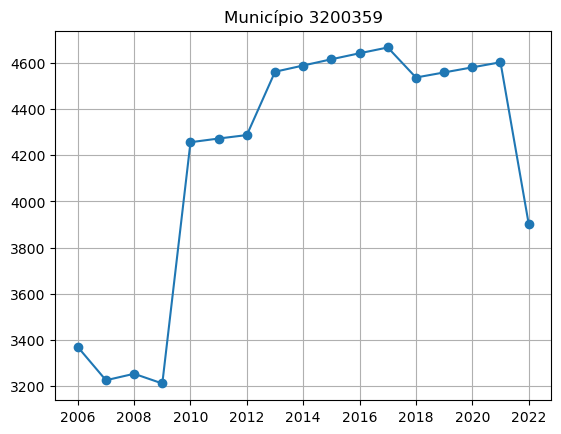

In [16]:
analisar_municipio(df_validado, '3200359')

In [17]:
df_validado, df_final = classificar_qualidade_populacao(df_validado, df_final)

print('✅ Flags de qualidade da população sincronizadas em df_final.')

✅ Flags de qualidade da população sincronizadas em df_final.


In [18]:
df_validado['tipo_erro'].value_counts()

tipo_erro
ok                   1239
municipio_pequeno      23
mudanca_base            5
Name: count, dtype: int64

In [19]:
df_validado[df_validado['tipo_erro'] != 'ok'][
    ['id_municipio', 'ano', 'populacao_ref', 'tipo_erro']
]

,id_municipio,ano,populacao_ref,tipo_erro
18,3200136,2007,2791.0,municipio_pequeno
75,3200300,2022,13002.0,municipio_pequeno
80,3200359,2010,4256.0,mudanca_base
97,3200409,2010,18161.0,municipio_pequeno
148,3200706,2010,6116.0,municipio_pequeno
210,3201001,2022,8315.0,municipio_pequeno
229,3201159,2007,2785.0,mudanca_base
232,3201159,2010,3416.0,municipio_pequeno
244,3201159,2022,2777.0,municipio_pequeno
331,3201704,2007,5420.0,municipio_pequeno


In [20]:
df_validado[df_validado['tipo_erro'] == 'mudanca_base']['id_municipio'].unique()

array(['3200359', '3201159', '3204302', '3204559', '3205150'],
      dtype=object)

In [25]:
# Cole isso logo ANTES da célula de exportação do parquet
print("Taxa_Morbidade no momento da exportação:")
print(f"  Não-nulos: {df_final['Taxa_Morbidade_100k_Hab'].notna().sum()}")
print(f"  Nulos: {df_final['Taxa_Morbidade_100k_Hab'].isna().sum()}")

Taxa_Morbidade no momento da exportação:
  Não-nulos: 1203
  Nulos: 64


# Exportação

In [22]:
# --- EXPORTAÇÃO DE ALTA PERFORMANCE (PARQUET) ---

# O formato Parquet preserva os tipos de dados (int, float, datetime)
# e oferece compressão superior ao CSV, ideal para o consumo no Streamlit.

try:
    PROCESSED = PROJECT_ROOT / "data" / "processed"
    PROCESSED.mkdir(parents=True, exist_ok=True)

    df_final.to_parquet(PROCESSED / "base_diamante_es_vfinal.parquet", index=False)
    print(f"🚀 Projeto finalizado com sucesso!")
    print(f"📦 Arquivo 'base_diamante_es_vfinal.parquet' gerado.")
    print(f"📊 Total de registros: {df_final.shape[0]}")
    print(f"💾 Tipos preservados: Internações permanecem como INT, Índices como FLOAT.")
except Exception as e:
    print(f"❌ Erro ao exportar para Parquet: {e}")
    # Fallback de segurança para CSV caso o ambiente falte dependência (pyarrow/fastparquet)
    df_final.to_csv('base_diamante_es_vfinal.csv', sep=';', index=False, encoding='utf-8-sig')
    print("⚠️ Exportado para CSV como alternativa de segurança.")


🚀 Projeto finalizado com sucesso!
📦 Arquivo 'base_diamante_es_vfinal.parquet' gerado.
📊 Total de registros: 1267
💾 Tipos preservados: Internações permanecem como INT, Índices como FLOAT.


In [21]:
# Diagnóstico da integração de saúde
print("1. Colunas de flags de saúde:")
print(df_final[['tem_dado_saude_agua', 'tem_dado_saude_esgoto', 'tem_dado_saude']].sum())

print("\n2. Coluna vetor_dominante_doenca (primeiras linhas não-nulas):")
print(df_final['vetor_dominante_doenca'].dropna().head(10))

print("\n3. Verificar se o arquivo de saúde foi carregado:")
# Troque pelo nome real da variável do seu df de saúde bruto
# Provavelmente algo como df_saude, df_tabnet, df_morbidade
# Se não souber, rode:
print([v for v in dir() if 'saude' in v.lower() or 'tabnet' in v.lower() or 'morbi' in v.lower()])

1. Colunas de flags de saúde:
tem_dado_saude_agua      1203
tem_dado_saude_esgoto    1017
tem_dado_saude           1203
dtype: int64

2. Coluna vetor_dominante_doenca (primeiras linhas não-nulas):
0     Sem Dados
1    Vetor Água
2    Vetor Água
3    Vetor Água
4    Vetor Água
5    Vetor Água
6    Vetor Água
7    Vetor Água
8    Vetor Água
9    Vetor Água
Name: vetor_dominante_doenca, dtype: object

3. Verificar se o arquivo de saúde foi carregado:
['integrar_saude_tabnet', 'processar_saude', 'tem_dado_saude']
